<a href="https://colab.research.google.com/github/Pablolpl/ml-finanzas/blob/main/ARIMA_SARIMA_y_redes_neuronales_(LSTM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de series temporales: ventas mensuales de alcohol
**Autor:** Pablo Lamas
**Máster en IA Aplicada al Sector Financiero – Instituto Europeo de Posgrado**

**Objetivo:** aplicar análisis exploratorio, modelado tradicional (ARIMA/SARIMA) y redes neuronales (LSTM) para predecir la serie de ventas mensuales de alcohol entre enero de 1992 y abril de 2025.

**Estructura:**
0. Configuración del entorno
1. Análisis exploratorio y preparación de los datos
2. Modelos tradicionales (ARIMA/SARIMA)
3. Modelado con redes neuronales (LSTM)
4. Conclusiones

## 0. Configuración del entorno

### 0.1 Activación de Keras 2
Desde la versión 2.16 de TensorFlow, Google Colab utiliza Keras 3, que eliminó la clase `TimeseriesGenerator` que pide el enunciado. Para poder usarla instalo el paquete `tf_keras` (Keras 2) y activo la variable de entorno `TF_USE_LEGACY_KERAS`.

Esta celda debe ejecutarse **antes de importar TensorFlow**, porque TensorFlow decide qué versión de Keras usar en el momento de importarse.

In [1]:
# Instalo Keras 2 (tf_keras) para disponer de TimeseriesGenerator
!pip install -q tf_keras

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # tensorflow.keras apuntará a Keras 2

### 0.2 Importación de librerías
- **pandas / numpy:** manipulación de datos y cálculo numérico.
- **matplotlib:** visualización.
- **statsmodels:** test ADF, funciones ACF/PACF, modelo SARIMA, test de Ljung-Box y descomposición estacional.
- **scikit-learn:** escalado (`MinMaxScaler`) y métricas de error.
- **TensorFlow/Keras:** `TimeseriesGenerator` y la red LSTM.

Fijo semillas aleatorias para que los resultados de la red neuronal sean reproducibles, ya que los pesos iniciales se generan al azar.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Formato por defecto de los gráficos
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


### 0.3 Carga del archivo
Subo el archivo `venta_alcohol.csv` desde mi equipo al entorno de Colab.

In [3]:
from google.colab import files

subido = files.upload()              # Abre el selector de archivos
RUTA = list(subido.keys())[0]        # Guarda el nombre del archivo subido
print("Archivo cargado:", RUTA)

Saving venta_alcohol.csv to venta_alcohol.csv
Archivo cargado: venta_alcohol.csv


# Parte 1 – Análisis exploratorio y preparación de los datos

## 1.1 Lectura del archivo y conversión de la fecha a índice datetime
Uso `read_csv` con dos parámetros clave:
- `parse_dates=[0]`: convierte la primera columna (fecha) de texto a tipo `datetime`.
- `index_col=0`: establece esa columna como índice del DataFrame. En series temporales el índice debe ser el tiempo.

Además renombro la columna de valores a `ventas`, fuerzo que sea numérica (cualquier valor no numérico pasa a NaN) y ordeno cronológicamente.

In [4]:
df = pd.read_csv(RUTA, parse_dates=[0], index_col=0)
print("Columnas originales:", list(df.columns))

df.columns = ["ventas"]                                        # Nombre uniforme
df.index.name = "fecha"
df["ventas"] = pd.to_numeric(df["ventas"], errors="coerce")   # Valores no numéricos -> NaN
df = df.sort_index()                                          # Orden cronológico

print("Tipo del índice:", df.index.dtype)
print("Rango:", df.index.min().date(), "→", df.index.max().date())
print("Observaciones:", len(df))
df.head()

Columnas originales: ['S4248SM144NCEN']
Tipo del índice: datetime64[ns]
Rango: 1992-01-01 → 2025-04-01
Observaciones: 400


,ventas
fecha,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


**Resultado:** el índice es de tipo `datetime64`, lo que confirma que la fecha se ha interpretado correctamente. La serie va del **1 de enero de 1992 al 1 de abril de 2025**, con **400 observaciones mensuales**. La columna de valores venía con el código de la serie en FRED (`S4248SM144NCEN`) y se ha renombrado a `ventas`.

## 1.2 Asignación de frecuencia mensual
Asigno frecuencia mensual con `asfreq('MS')` (*Month Start*: una observación el día 1 de cada mes). Antes normalizo todas las fechas al primer día del mes: si el archivo trajera fechas de fin de mes, `asfreq('MS')` no encontraría coincidencias y dejaría la serie vacía.

`asfreq` tiene una segunda función importante: **si falta algún mes en el archivo, lo inserta con valor NaN**, lo que permite detectar los huecos en el paso siguiente.

## 1.3 Verificación de valores faltantes
Identifico los meses sin dato y los represento sobre la serie (líneas rojas) para ver si son huecos aislados o consecutivos.

Número de valores faltantes: 0 (0.00% de la serie)
Períodos con valores faltantes: []


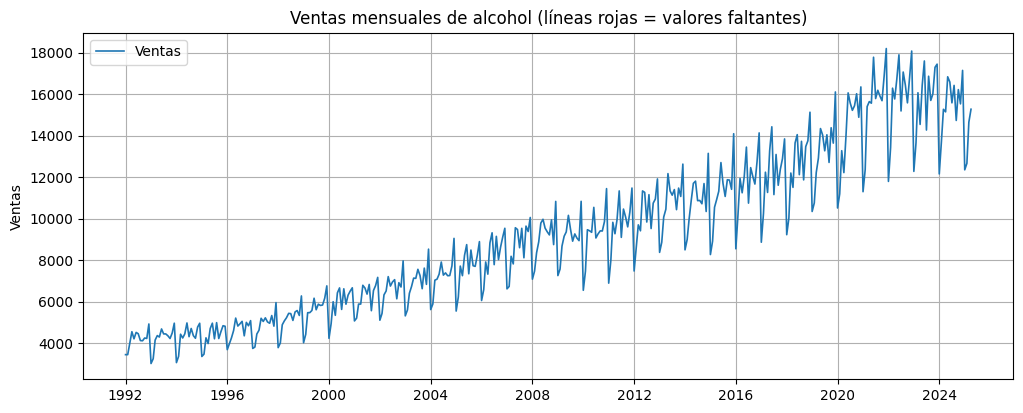

In [5]:
faltantes = df[df["ventas"].isna()]
print(f"Número de valores faltantes: {len(faltantes)} ({len(faltantes)/len(df):.2%} de la serie)")
print("Períodos con valores faltantes:", faltantes.index.strftime("%Y-%m").tolist())

fig, ax = plt.subplots()
ax.plot(df["ventas"], lw=1.2, label="Ventas")
for f in faltantes.index:
    ax.axvline(f, color="red", alpha=0.4)
ax.set_title("Ventas mensuales de alcohol (líneas rojas = valores faltantes)")
ax.set_ylabel("Ventas")
ax.legend()
plt.show()

**Resultado:** la serie **no tiene valores faltantes** (0 de 400 observaciones, 0,00%). Tras aplicar `asfreq('MS')` el número de observaciones sigue siendo 400, que es exactamente el número de meses entre enero de 1992 y abril de 2025 (33 años × 12 + 4 meses). Por tanto, no falta ningún mes en el archivo ni hay valores vacíos o no numéricos, y en el gráfico no aparece ninguna línea roja.

## 1.4 Estrategia de imputación
Aunque en este caso no hay huecos que rellenar, dejo definida y aplicada la estrategia, de forma que el proceso sería válido si llegaran datos incompletos (por ejemplo, en una actualización del archivo).

**Estrategia propuesta: interpolación temporal** (`interpolate(method="time")`), que estima cada valor faltante sobre la recta que une el mes anterior y el posterior.

Justificación frente a otras alternativas:
- **Eliminar filas:** no es viable en series temporales, porque rompe la frecuencia mensual y desplaza los rezagos que usan tanto el SARIMA como la LSTM.
- **Rellenar con la media:** ignora la tendencia creciente y la estacionalidad. La media global (unos 9.185) está muy lejos tanto de los valores de 1992 como de los de 2024 y generaría saltos artificiales.
- **Repetir el mes anterior (`ffill`):** en una serie con estacionalidad marcada introduce errores claros (por ejemplo, copiar noviembre en diciembre).
- **Interpolación:** genera un valor coherente con los meses contiguos y respeta la tendencia local.

**Limitación:** si el hueco coincidiera con un pico estacional (por ejemplo, diciembre), la interpolación lineal lo infravaloraría. En ese caso una alternativa mejor sería usar el valor del mismo mes del año anterior ajustado por el crecimiento.

In [6]:
df["imputado"] = df["ventas"].isna()      # Marco los meses que se van a imputar
df["ventas"] = df["ventas"].interpolate(method="time").bfill().ffill()
# bfill/ffill solo actúan si el hueco estuviera en el primer o último dato

print("Faltantes tras imputar:", df["ventas"].isna().sum())

# Comprobación: valor imputado frente al mes anterior y al siguiente
chequeo = pd.DataFrame({
    "mes_anterior": df["ventas"].shift(1),
    "imputado": df["ventas"],
    "mes_siguiente": df["ventas"].shift(-1),
})[df["imputado"]].round(1)
chequeo

Faltantes tras imputar: 0


,mes_anterior,imputado,mes_siguiente
fecha,,,


**Resultado:** tras aplicar la estrategia siguen quedando 0 valores faltantes y la tabla de comprobación sale vacía, porque no ha habido que imputar ningún mes. La serie se mantiene exactamente igual que la original.

## 1.5 Estadísticos principales de la variable ventas
Calculo media, mediana, desviación estándar, mínimo y máximo, junto con las fechas en que se alcanzan el mínimo y el máximo, y complemento con `describe()`.

In [7]:
estad = pd.Series({
    "Media": df["ventas"].mean(),
    "Mediana": df["ventas"].median(),
    "Desviación estándar": df["ventas"].std(),
    "Mínimo": df["ventas"].min(),
    "Máximo": df["ventas"].max(),
}).round(2)
print(estad)
print("\nFecha del mínimo:", df["ventas"].idxmin().strftime("%Y-%m"))
print("Fecha del máximo:", df["ventas"].idxmax().strftime("%Y-%m"))

df["ventas"].describe()

Media                   9184.81
Mediana                 8898.50
Desviación estándar     3881.76
Mínimo                  3031.00
Máximo                 18201.00
dtype: float64

Fecha del mínimo: 1993-01
Fecha del máximo: 2021-12


,ventas
count,400.000000
mean,9184.810000
std,3881.764401
min,3031.000000
25%,5634.250000
50%,8898.500000
75%,11867.250000
max,18201.000000


**Comentario de los estadísticos:**

| Estadístico | Valor |
|---|---|
| Media | 9.184,81 |
| Mediana | 8.898,50 |
| Desviación estándar | 3.881,76 |
| Mínimo | 3.031 (enero de 1993) |
| Máximo | 18.201 (diciembre de 2021) |

- **Media vs. mediana:** la media es algo mayor que la mediana, lo que indica una ligera **asimetría positiva**. Los valores altos de los últimos años tiran de la media hacia arriba.
- **Desviación estándar:** equivale a un coeficiente de variación del **42%** (3.881,76 / 9.184,81), muy elevado. No refleja volatilidad mes a mes, sino el **crecimiento de largo plazo**: la serie mezcla niveles de los años noventa (entre 3.000 y 5.000) con niveles recientes (entre 12.000 y 18.000). El rango intercuartílico lo confirma: el 50% central de los datos va de 5.634 a 11.867.
- **Mínimo y máximo:** el mínimo está en un **enero** al inicio de la serie y el máximo en un **diciembre** reciente, y el máximo es **6 veces** el mínimo. Solo con estas dos fechas ya se intuyen una **tendencia creciente** y una **estacionalidad** con picos en diciembre y valles en enero.

## 1.6 Visualización exploratoria
Represento la serie completa, su distribución, la media por mes del año y la descomposición en tendencia, estacionalidad y residuo (`period=12`, ya que el patrón es anual).

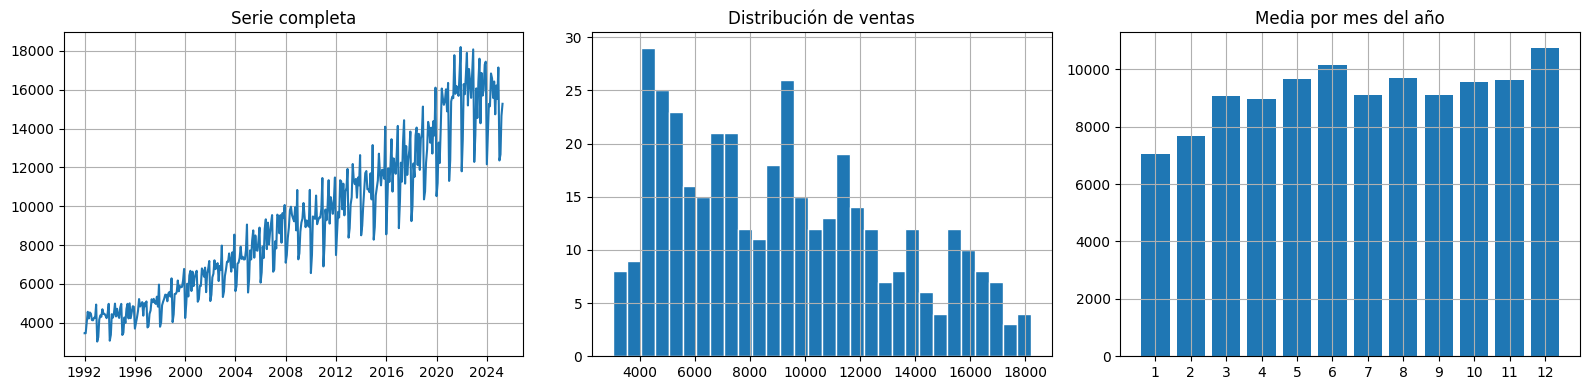

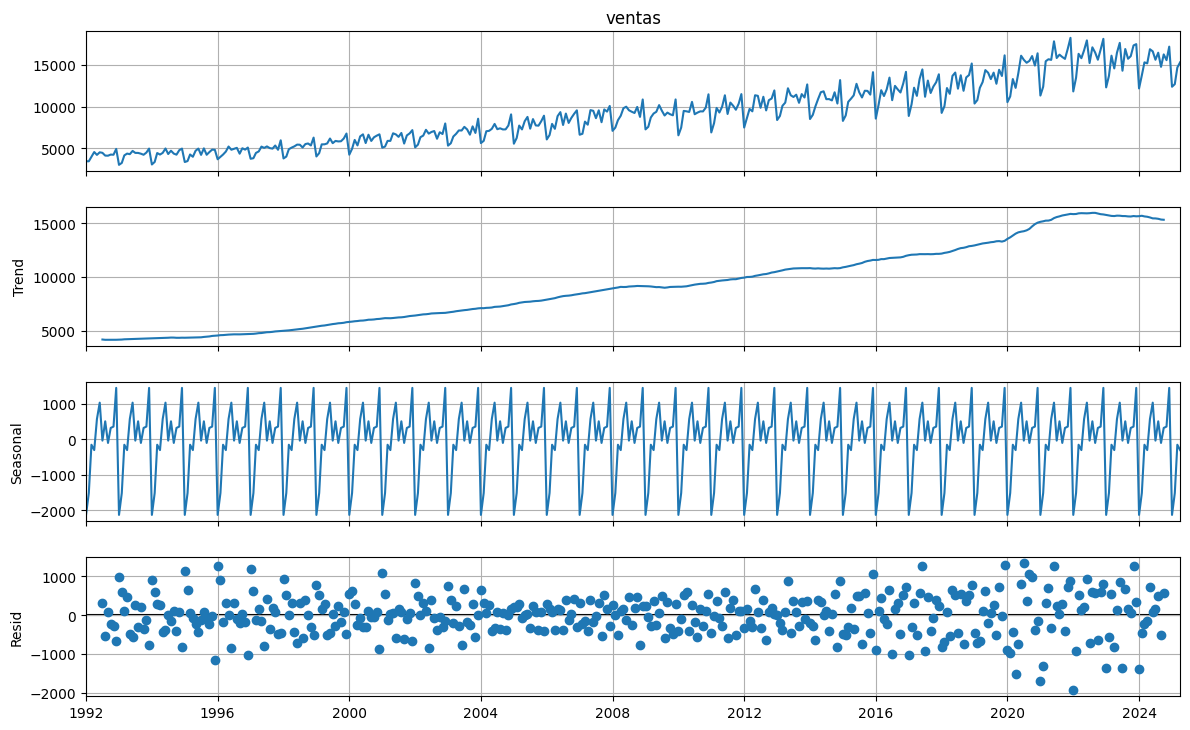

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(df["ventas"]); axes[0].set_title("Serie completa")
axes[1].hist(df["ventas"], bins=30, edgecolor="white"); axes[1].set_title("Distribución de ventas")
perfil = df.groupby(df.index.month)["ventas"].mean()
axes[2].bar(perfil.index, perfil.values); axes[2].set_title("Media por mes del año")
axes[2].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()

# Descomposición aditiva
seasonal_decompose(df["ventas"], model="additive", period=12).plot()
plt.gcf().set_size_inches(12, 8)
plt.show()

**Comentario del análisis exploratorio:**
- **Tendencia:** crecimiento sostenido desde 1992 hasta 2021, con una aceleración en 2020–2021 que coincide con el aumento del consumo en el hogar durante la pandemia. **A partir de 2022 la tendencia se frena y en 2023–2024 las ventas se estancan e incluso retroceden.** Este cambio será relevante en la Parte 3, porque el periodo de test (desde junio de 2023) coincide con esa fase de estancamiento.
- **Estacionalidad:** patrón anual muy marcado. En el gráfico de medias por mes, **diciembre es el mes de mayores ventas** (campaña navideña) y **enero el más bajo**, seguido de febrero. Junio presenta un segundo pico, previo a la temporada de verano. Esto confirma un componente estacional con **s = 12**.
- **Heterocedasticidad:** la amplitud de las oscilaciones estacionales crece a medida que sube el nivel de la serie. La caída de diciembre a enero es de unos 1.500 en los primeros años y de unos 5.000–6.000 en los últimos. La descomposición aditiva lo refleja en un residuo cuya dispersión aumenta al final de la serie.
- **Distribución:** el histograma no es normal; es una mezcla de los distintos niveles que ha ido alcanzando la serie a lo largo del tiempo.
- **Conclusión:** con tendencia y estacionalidad, la serie no tiene media constante, por lo que previsiblemente **no es estacionaria**. Lo contrasto formalmente en la Parte 2.

# Parte 2 – Modelos tradicionales (ARIMA / SARIMA)

## 2.1 Test de Dickey-Fuller aumentado (ADF)
Los modelos ARIMA requieren una serie estacionaria (media y varianza constantes en el tiempo). El test ADF lo contrasta:
- **H₀:** la serie tiene raíz unitaria, es decir, **no es estacionaria**.
- **H₁:** la serie es estacionaria.
- **Regla de decisión:** si el p-valor es menor que 0,05 (o el estadístico es más negativo que el valor crítico del 5%), se rechaza H₀.

Defino una función para poder repetir el test tras cada transformación.

In [9]:
def test_adf(serie, nombre):
    res = adfuller(serie.dropna(), autolag="AIC")   # autolag elige el nº de rezagos por AIC
    print(f"--- Test ADF: {nombre} ---")
    print(f"Estadístico ADF: {res[0]:.4f}")
    print(f"p-valor        : {res[1]:.4f}")
    for k, v in res[4].items():
        print(f"Valor crítico {k}: {v:.4f}")
    if res[1] < 0.05:
        print("→ Se rechaza H0: la serie es ESTACIONARIA\n")
    else:
        print("→ No se rechaza H0: la serie NO es estacionaria\n")

test_adf(df["ventas"], "serie original")

--- Test ADF: serie original ---
Estadístico ADF: -0.3046
p-valor        : 0.9248
Valor crítico 1%: -3.4476
Valor crítico 5%: -2.8691
Valor crítico 10%: -2.5708
→ No se rechaza H0: la serie NO es estacionaria



**Interpretación:** el estadístico ADF es **−0,3046**, muy lejos del valor crítico del 5% (−2,8691), y el **p-valor es 0,9248**, muy superior a 0,05. **No se rechaza H₀: la serie original no es estacionaria**, como se anticipaba por su tendencia creciente. Es necesario diferenciarla.

## 2.2 Diferenciación de la serie
Aplico dos diferencias:
1. **Diferencia regular (d = 1):** yₜ − yₜ₋₁. Elimina la tendencia.
2. **Diferencia estacional (D = 1, s = 12):** resta el valor del mismo mes del año anterior. Elimina el patrón anual.

Repito el ADF tras cada diferencia para ver qué aporta cada una.

--- Test ADF: diferencia regular (d=1) ---
Estadístico ADF: -3.4015
p-valor        : 0.0109
Valor crítico 1%: -3.4476
Valor crítico 5%: -2.8692
Valor crítico 10%: -2.5708
→ Se rechaza H0: la serie es ESTACIONARIA

--- Test ADF: diferencia regular + estacional (d=1, D=1, s=12) ---
Estadístico ADF: -6.9310
p-valor        : 0.0000
Valor crítico 1%: -3.4481
Valor crítico 5%: -2.8694
Valor crítico 10%: -2.5709
→ Se rechaza H0: la serie es ESTACIONARIA



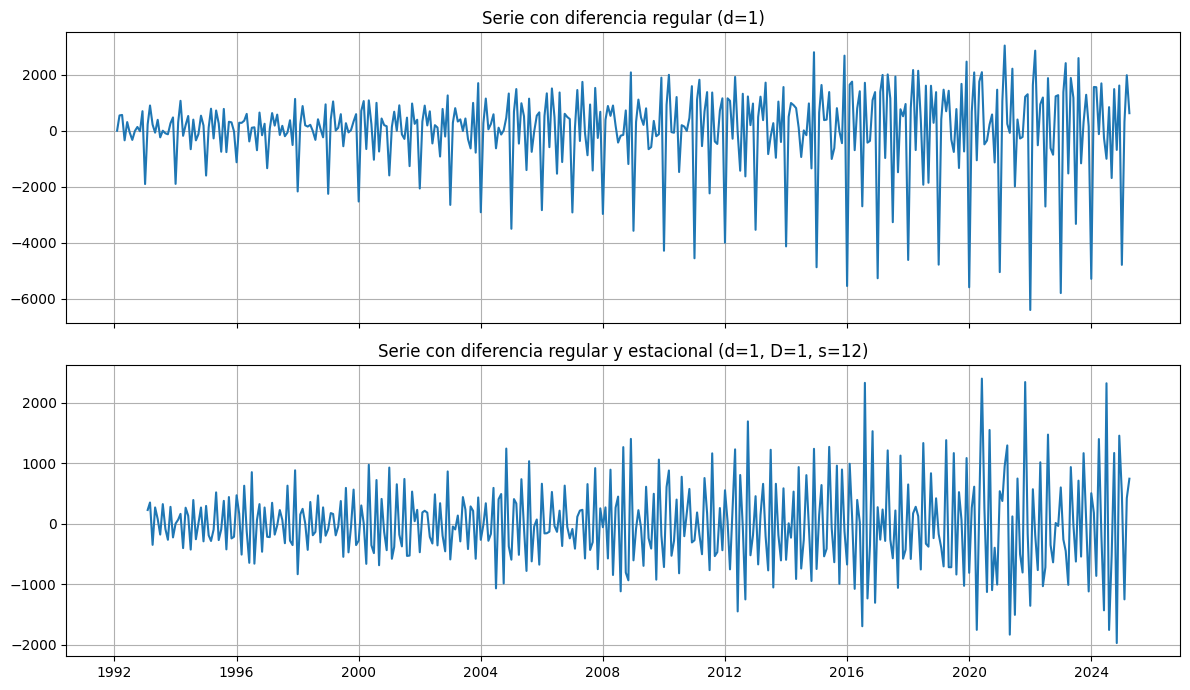

In [10]:
diff1 = df["ventas"].diff().dropna()        # Diferencia regular
diff1_12 = diff1.diff(12).dropna()          # Diferencia estacional sobre la anterior

test_adf(diff1, "diferencia regular (d=1)")
test_adf(diff1_12, "diferencia regular + estacional (d=1, D=1, s=12)")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(diff1); axes[0].set_title("Serie con diferencia regular (d=1)")
axes[1].plot(diff1_12); axes[1].set_title("Serie con diferencia regular y estacional (d=1, D=1, s=12)")
plt.tight_layout(); plt.show()

**Interpretación:**

| Serie | Estadístico ADF | p-valor | Conclusión |
|---|---|---|---|
| Original | −0,3046 | 0,9248 | No estacionaria |
| Diferencia regular (d = 1) | −3,4015 | 0,0109 | Estacionaria al 5%, no al 1% |
| Diferencia regular + estacional (d = 1, D = 1) | −6,9310 | 0,0000 | Estacionaria con holgura |

- Con la **diferencia regular**, el p-valor (0,0109) ya es menor que 0,05, pero el estadístico (−3,40) no llega al valor crítico del 1% (−3,45), y el gráfico sigue mostrando un **patrón anual muy marcado**: cada enero hay una caída brusca y cada diciembre un pico. El ADF está diseñado para raíces unitarias regulares y no recoge bien la no estacionariedad estacional.
- Con la **diferencia regular y estacional**, el estadístico baja a −6,93 (p-valor ≈ 0) y la serie oscila alrededor de cero sin patrón estacional sistemático. Se observa, eso sí, que **la variabilidad aumenta a partir de 2020**, lo que confirma la heterocedasticidad detectada en la Parte 1.

**Decisión:** d = 1, D = 1, s = 12.

## 2.3 Gráficos ACF y PACF
Represento la función de autocorrelación (ACF) y la de autocorrelación parcial (PACF) de la serie diferenciada con 48 rezagos (cuatro años), para ver tanto la parte regular como la estacional (rezagos 12, 24, 36 y 48, marcados con líneas punteadas).
- La **ACF** orienta los órdenes MA (q y Q).
- La **PACF** orienta los órdenes AR (p y P).

Como apoyo numérico, calculo qué rezagos superan la banda de significación ±1,96/√n.

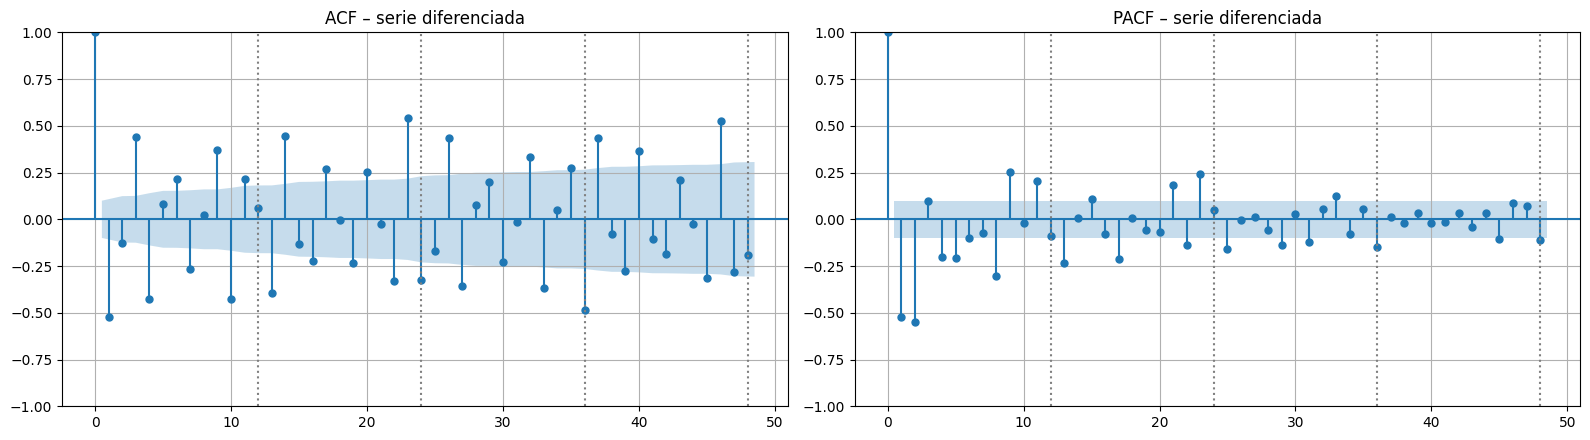

Banda de significación: ±0.100
ACF significativa en rezagos : [1, 2, 3, 4, 6, 7, 9, 10, 11, 13, 14, 15, 16, 17, 19, 20, 22, 23, 24, 25, 26, 27, 29, 30, 32, 33, 35, 36]
PACF significativa en rezagos: [1, 2, 4, 5, 8, 9, 11, 13, 15, 17, 21, 22, 23, 25, 29, 31, 33, 36]


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_acf(diff1_12, lags=48, ax=axes[0], title="ACF – serie diferenciada")
plot_pacf(diff1_12, lags=48, ax=axes[1], method="ywm", title="PACF – serie diferenciada")
for ax in axes:
    for l in (12, 24, 36, 48):
        ax.axvline(l, color="grey", ls=":")
plt.tight_layout(); plt.show()

# Rezagos significativos
banda = 1.96 / np.sqrt(len(diff1_12))
acf_v = acf(diff1_12, nlags=36)
pacf_v = pacf(diff1_12, nlags=36, method="ywm")
print(f"Banda de significación: ±{banda:.3f}")
print("ACF significativa en rezagos :", [i for i in range(1, 37) if abs(acf_v[i]) > banda])
print("PACF significativa en rezagos:", [i for i in range(1, 37) if abs(pacf_v[i]) > banda])

**Lectura de los gráficos** (banda de significación ±0,10):
- **ACF:** el rezago 1 es fuertemente negativo (en torno a −0,5), algo típico de una serie diferenciada que apunta a un término **MA(1)**. A partir de ahí la ACF no decae de forma limpia: presenta un **patrón oscilante**, con picos alternos positivos y negativos (por ejemplo, en los rezagos 3–4 y 9–10) que se repite a lo largo de todos los rezagos. Por eso aparecen tantos rezagos significativos en la lista.
- **PACF:** los primeros rezagos (1 y 2) son claramente los más fuertes, ambos negativos, y a partir de ahí los valores son mucho menores.
- **Parte estacional:** la PACF no es significativa en los rezagos 12 ni 24, lo que no respalda un término AR estacional. En la ACF el rezago 12 tampoco destaca: la firma estacional queda oculta por el patrón oscilante.

**Origen del patrón oscilante:** esta serie corresponde a ventas mayoristas, que dependen mucho del **número de días hábiles y de fines de semana de cada mes** (efecto calendario). Como la composición de días de la semana de cada mes cambia de un año a otro, se genera una autocorrelación que un SARIMA de órdenes bajos no puede capturar. Es un rasgo real de los datos y lo tengo en cuenta al interpretar los residuos.

## 2.4 Propuesta del modelo: SARIMA(1,1,1)(0,1,1)₁₂

| Parte | Observación en los gráficos | Orden |
|---|---|---|
| Regular AR | La PACF concentra sus picos en los primeros rezagos y cae después; parto de un término AR como especificación parsimoniosa | **p = 1** |
| Regular MA | La ACF presenta un pico negativo fuerte en el rezago 1 | **q = 1** |
| Estacional AR | La PACF no es significativa en los rezagos 12 y 24 | **P = 0** |
| Estacional MA | Especificación estándar tras una diferencia estacional, que corrige la correlación negativa que la propia diferenciación introduce en el rezago 12. Se valida con la significación del coeficiente | **Q = 1** |
| Diferencias | Según el test ADF (apartados 2.1 y 2.2) | **d = 1, D = 1** |
| Periodo | Estacionalidad anual en datos mensuales | **s = 12** |

El modelo propuesto amplía el *airline model* de Box-Jenkins, SARIMA(0,1,1)(0,1,1)₁₂, estándar para series mensuales con tendencia y estacionalidad. Como apoyo, comparo tres especificaciones mediante AIC y BIC (cuanto más bajos, mejor equilibrio entre ajuste y complejidad).

In [12]:
def ajustar_sarima(orden, orden_est):
    return SARIMAX(df["ventas"], order=orden, seasonal_order=orden_est,
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)

candidatos = {
    "SARIMA(1,1,1)(0,1,1,12) – propuesto": ((1,1,1), (0,1,1,12)),
    "SARIMA(0,1,1)(0,1,1,12) – airline":   ((0,1,1), (0,1,1,12)),
    "SARIMA(1,1,1)(1,1,1,12)":             ((1,1,1), (1,1,1,12)),
}
for nombre, (o, s) in candidatos.items():
    m = ajustar_sarima(o, s)
    print(f"{nombre}: AIC = {m.aic:.1f} | BIC = {m.bic:.1f}")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA(1,1,1)(0,1,1,12) – propuesto: AIC = 5683.6 | BIC = 5699.3


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA(0,1,1)(0,1,1,12) – airline: AIC = 5701.1 | BIC = 5712.8


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA(1,1,1)(1,1,1,12): AIC = 5658.2 | BIC = 5677.8


**Comparación:**

| Modelo | AIC | BIC |
|---|---|---|
| SARIMA(1,1,1)(1,1,1)₁₂ | 5.658,2 | 5.677,8 |
| **SARIMA(1,1,1)(0,1,1)₁₂ – propuesto** | **5.683,6** | **5.699,3** |
| SARIMA(0,1,1)(0,1,1)₁₂ – airline | 5.701,1 | 5.712,8 |

- El modelo propuesto **mejora al airline** (unos 18 puntos menos de AIC), lo que confirma que el término AR(1) aporta información.
- El modelo con AR estacional (P = 1) obtiene un AIC 25 puntos menor, una mejora relevante. Sin embargo, la PACF no es significativa en los rezagos estacionales, así que los gráficos no respaldan ese término. **Mantengo P = 0 como modelo base, por parsimonia y coherencia con la identificación gráfica**, y dejo P = 1 como la primera extensión a considerar.

## 2.5 Ajuste del modelo y extracción de residuos
Ajusto el SARIMA(1,1,1)(0,1,1)₁₂ y extraigo los residuos (valor real menos valor ajustado), que representan lo que el modelo no explica.

Descarto los **13 primeros residuos** (d + D·s = 1 + 12): el modelo no dispone de historia suficiente para calcularlos correctamente, por lo que son anormalmente grandes y distorsionarían el diagnóstico.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                             ventas   No. Observations:                  400
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2837.795
Date:                            Sat, 26 Sep 2026   AIC                           5683.590
Time:                                    09:47:11   BIC                           5699.276
Sample:                                01-01-1992   HQIC                          5689.819
                                     - 04-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2658      0.051     -5.238      0.000      -0.365      -0.166
ma.L1         -0.7305      0.031   

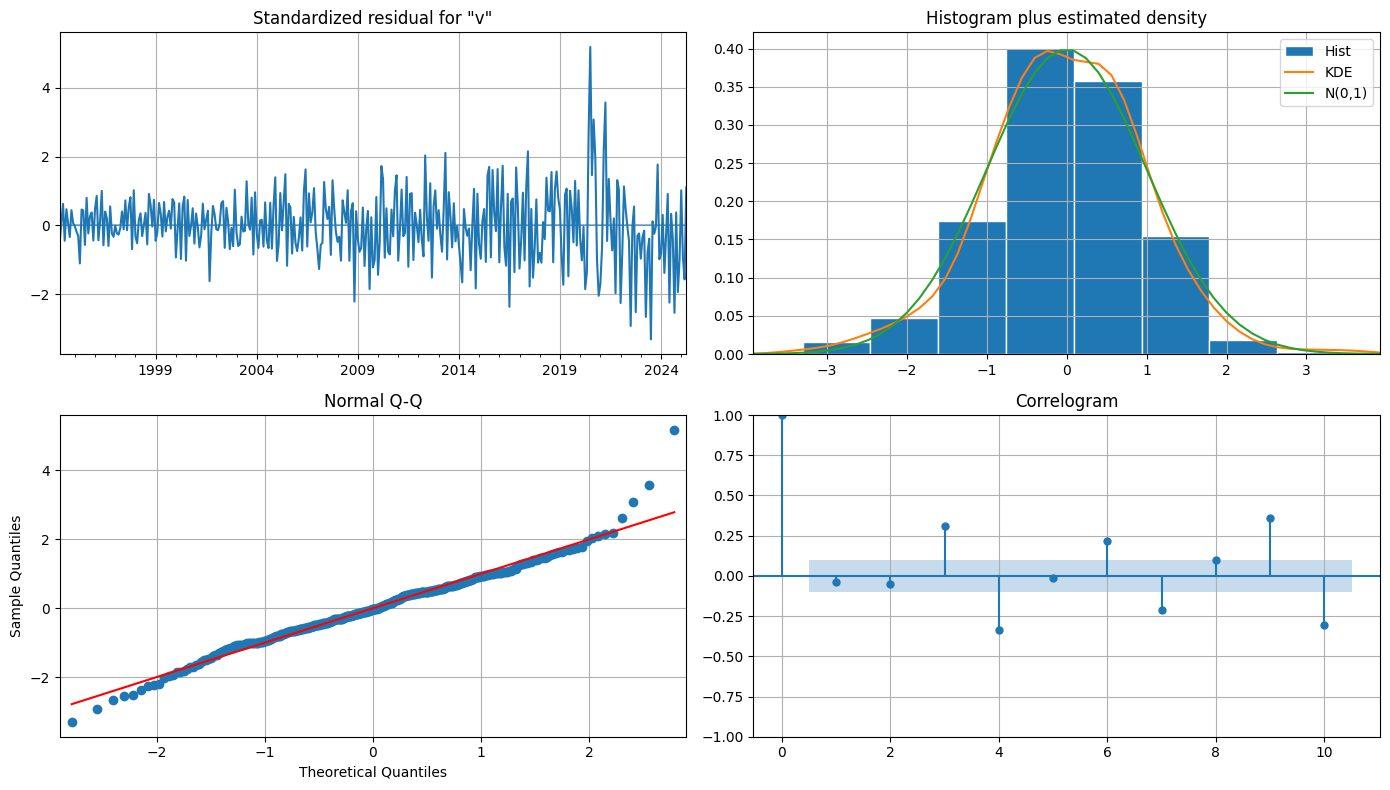

In [13]:
modelo_sarima = ajustar_sarima((1,1,1), (0,1,1,12))
print(modelo_sarima.summary())

residuos = modelo_sarima.resid.iloc[13:]
print(f"\nMedia de los residuos: {residuos.mean():.3f}")
print(f"Desviación estándar  : {residuos.std():.3f}")

modelo_sarima.plot_diagnostics(figsize=(14, 8))
plt.tight_layout(); plt.show()

**Lectura del diagnóstico:**
- **Coeficientes:** los tres términos son significativos al 1% (p = 0,000): ar.L1 = −0,27, ma.L1 = −0,73 y ma.S.L12 = −0,67. El coeficiente MA estacional, grande y muy significativo, **valida la elección de Q = 1**, aunque no se viera con claridad en la ACF.
- **Media de los residuos:** 0,40, prácticamente cero frente a una desviación estándar de 481,6, así que el modelo no tiene sesgo sistemático.
- **Residuos estandarizados:** oscilan alrededor de cero, pero **su amplitud aumenta claramente en los últimos años**, con los mayores valores en 2020–2021 (el residuo más grande corresponde a mediados de 2020, en plena pandemia). El test de heterocedasticidad del resumen lo confirma: H = 6,51 con p = 0,00, es decir, la varianza de los residuos al final de la muestra es más de seis veces la del principio.
- **Histograma y Q-Q plot:** colas más pesadas que la normal (curtosis de 5,18 frente a 3 de la normal; Jarque-Bera = 78,54 con p = 0,00), debido a los meses atípicos de 2020–2021.
- **Correlograma:** el rezago 1 queda limpio (Ljung-Box en L1: p = 0,44), pero siguen apareciendo barras fuera de la banda en rezagos intermedios, consecuencia del efecto calendario descrito en 2.3.

## 2.6 Prueba de Ljung-Box sobre los residuos (lags 12 y 24)
Contrasta si los residuos presentan autocorrelación de forma conjunta en los primeros 12 y 24 rezagos (uno y dos ciclos anuales):
- **H₀:** los residuos no están autocorrelacionados, es decir, son **ruido blanco**.
- **H₁:** existe autocorrelación en los residuos.
- **Si p > 0,05**, no se rechaza H₀: el modelo ha capturado la estructura de la serie.

In [14]:
lb = acorr_ljungbox(residuos, lags=[12, 24], return_df=True)
print(lb.round(4))
print()
for lag, fila in lb.iterrows():
    p = fila["lb_pvalue"]
    if p > 0.05:
        print(f"Lag {lag}: p = {p:.4f} > 0,05 → no se rechaza H0 → ruido blanco")
    else:
        print(f"Lag {lag}: p = {p:.4f} ≤ 0,05 → se rechaza H0 → queda autocorrelación")

     lb_stat  lb_pvalue
12  242.0993        0.0
24  523.2286        0.0

Lag 12: p = 0.0000 ≤ 0,05 → se rechaza H0 → queda autocorrelación
Lag 24: p = 0.0000 ≤ 0,05 → se rechaza H0 → queda autocorrelación


**Interpretación del test de Ljung-Box:**

| Lag | Estadístico Q | p-valor | Conclusión |
|---|---|---|---|
| 12 | 242,10 | 0,0000 | Se rechaza H₀ |
| 24 | 523,23 | 0,0000 | Se rechaza H₀ |

**Se rechaza H₀ en ambos rezagos: los residuos no se comportan como ruido blanco.** Queda estructura de dependencia que el modelo no ha capturado.

Esto no significa que el modelo sea inútil. Ha capturado lo esencial (la tendencia, la estacionalidad anual y la dependencia del primer rezago, que queda limpia según el Ljung-Box en L1), pero no es un modelo estadísticamente completo. Las causas identificadas son:
1. **Efecto calendario:** la variación del número de días hábiles y fines de semana de cada mes genera la autocorrelación oscilante vista en la ACF, que un SARIMA no puede reproducir.
2. **Heterocedasticidad:** la varianza de los residuos crece con el tiempo (H = 6,51), lo que incumple uno de los supuestos del modelo.
3. **Cambio estructural de 2020–2021:** la pandemia produjo meses atípicos que generan los mayores residuos.
4. **Tamaño muestral:** con unas 390 observaciones el test tiene mucha potencia y detecta incluso autocorrelaciones pequeñas.

**Mejoras posibles:** ampliar la parte AR (la PACF sugiere un segundo rezago) o añadir P = 1, que ya mejora el AIC; modelar el **logaritmo** de las ventas para estabilizar la varianza; incluir **regresores de calendario** (número de días hábiles del mes) en un SARIMAX; y añadir una **variable ficticia** para el periodo de la pandemia.

# Parte 3 – Modelado con redes neuronales (LSTM)

## 3.1 División en entrenamiento y test
- **Entrenamiento:** datos anteriores al 1 de junio de 2023.
- **Test:** desde junio de 2023 hasta el final de la serie.

La división es **cronológica y no aleatoria**: el modelo solo puede aprender del pasado para predecir el futuro. Mezclar fechas introduciría información futura en el entrenamiento (*data leakage*).

Entrenamiento: 1992-01 → 2023-05 (377 meses)
Test         : 2023-06 → 2025-04 (23 meses)


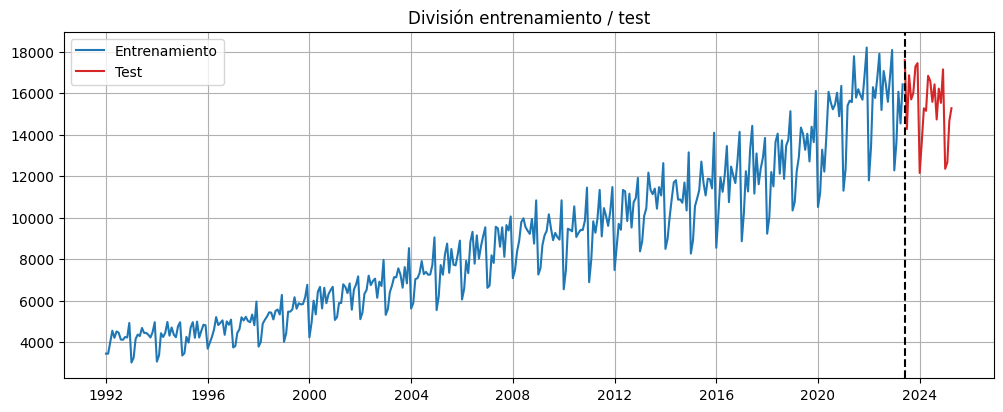

In [15]:
FECHA_CORTE = "2023-06-01"
serie = df[["ventas"]]          # Doble corchete: formato tabla (2D), necesario para el escalador

train = serie[serie.index < FECHA_CORTE]
test = serie[serie.index >= FECHA_CORTE]

print(f"Entrenamiento: {train.index.min():%Y-%m} → {train.index.max():%Y-%m} ({len(train)} meses)")
print(f"Test         : {test.index.min():%Y-%m} → {test.index.max():%Y-%m} ({len(test)} meses)")

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Test", color="C3")
plt.axvline(pd.Timestamp(FECHA_CORTE), color="k", ls="--")
plt.title("División entrenamiento / test")
plt.legend(); plt.show()

## 3.2 Escalado de la serie
Normalizo las ventas al rango [0, 1] con `MinMaxScaler`, que aplica (x − mín) / (máx − mín):
- Las LSTM utilizan funciones de activación `tanh` y `sigmoid`, que se saturan con valores grandes. Con los datos en [0, 1], el gradiente fluye mejor y el entrenamiento converge más rápido.
- **El escalador se ajusta solo con los datos de entrenamiento** (`fit_transform` en train, `transform` en test). Ajustarlo con toda la serie filtraría al modelo el mínimo y el máximo del periodo de test.

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_esc = scaler.fit_transform(train)   # Aprende mín/máx SOLO de train
test_esc = scaler.transform(test)         # Aplica ese mismo mín/máx al test

print(f"Train escalado: mín = {train_esc.min():.3f} | máx = {train_esc.max():.3f}")
print(f"Test escalado : mín = {test_esc.min():.3f} | máx = {test_esc.max():.3f}")

Train escalado: mín = 0.000 | máx = 1.000
Test escalado : mín = 0.602 | máx = 0.961


**Resultado:** el test escalado se mueve entre **0,602 y 0,961**, dentro del rango [0, 1]. Como las ventas del test no superan el máximo histórico (diciembre de 2021), **la red no tiene que extrapolar fuera del rango de valores que ha visto** durante el entrenamiento. Además, el entrenamiento abarca 377 meses y el test 23 (aproximadamente un 94% / 6%), y el test coincide con la fase de estancamiento de las ventas.

## 3.3 Estructuración de los datos con TimeseriesGenerator
La LSTM necesita ejemplos del tipo "ventana de meses pasados → mes siguiente", en formato 3D (muestras, pasos temporales, variables). `TimeseriesGenerator` los genera automáticamente:
- Ejemplo 1: meses 1 a 12 → mes 13
- Ejemplo 2: meses 2 a 13 → mes 14
- ...

**Parámetros elegidos:**

| Parámetro | Valor | Justificación |
|---|---|---|
| `data` y `targets` | serie escalada | Modelo autorregresivo univariante: la serie se predice con su propio pasado |
| `length` | **12** | Cada predicción ve un ciclo estacional completo, coherente con s = 12 del SARIMA |
| `sampling_rate` | 1 | Se usan todos los meses de la ventana, sin saltos |
| `stride` | 1 | Las ventanas avanzan de mes en mes, lo que maximiza el número de ejemplos |
| `batch_size` | **1** | Con pocas muestras (365), los pesos se actualizan tras cada ejemplo y el modelo aprende más por época |

**Generador de test:** para predecir el primer mes de test (junio de 2023) hacen falta los 12 meses anteriores, que están en entrenamiento. Por eso añado al inicio del test los últimos 12 meses de entrenamiento. No hay fuga de información, porque son datos pasados. Cada predicción se hace **un paso adelante**, con valores reales como entrada.

In [17]:
N_INPUT = 12      # Longitud de la ventana (meses)
N_FEATURES = 1    # Serie univariante

generador_train = TimeseriesGenerator(train_esc, train_esc,
                                      length=N_INPUT, sampling_rate=1,
                                      stride=1, batch_size=1)

datos_test = np.concatenate([train_esc[-N_INPUT:], test_esc])
generador_test = TimeseriesGenerator(datos_test, datos_test,
                                     length=N_INPUT, sampling_rate=1,
                                     stride=1, batch_size=1)

X0, y0 = generador_train[0]
print("Muestras de entrenamiento:", len(generador_train))
print("Muestras de test         :", len(generador_test))
print("Forma de cada entrada    :", X0.shape, "→ (batch, pasos, variables)")
print("Primera ventana :", X0.flatten().round(3))
print("Objetivo (mes 13):", y0.flatten().round(3))

Muestras de entrenamiento: 365
Muestras de test         : 23
Forma de cada entrada    : (1, 12, 1) → (batch, pasos, variables)
Primera ventana : [0.028 0.028 0.064 0.101 0.078 0.099 0.095 0.073 0.072 0.081 0.08  0.126]
Objetivo (mes 13): [0.]


**Resultado:** se generan **365 ejemplos de entrenamiento** (377 meses − 12 de la primera ventana) y **23 de test**, uno por cada mes de test. Cada entrada tiene forma **(1, 12, 1)**: un ejemplo, 12 meses y 1 variable. El primer ejemplo usa los 12 meses de 1992 para predecir enero de 1993, cuyo valor escalado es 0 porque es el mínimo de toda la serie de entrenamiento.

## 3.4 Construcción del modelo LSTM

| Elección | Valor | Justificación |
|---|---|---|
| Arquitectura | 1 capa LSTM + 1 capa Dense | El enunciado pide un modelo simple; con 365 ejemplos, una red profunda sobreajustaría |
| Neuronas LSTM | **50** | Capacidad suficiente para captar tendencia y estacionalidad sin exceso de parámetros |
| Activación LSTM | **tanh** | Activación estándar de la LSTM, acotada entre −1 y 1 |
| Capa de salida | **Dense(1)**, lineal | Regresión: predice un único valor (las ventas del mes siguiente) |
| Optimizador | **Adam** | Ajusta la tasa de aprendizaje de forma adaptativa y es robusto sin apenas calibración |
| Función de pérdida | **MSE** | Estándar en regresión; penaliza más los errores grandes |

El modelo resultante tiene **10.451 parámetros entrenables** (10.400 en la capa LSTM y 51 en la de salida).

In [18]:
modelo_lstm = Sequential([
    Input(shape=(N_INPUT, N_FEATURES)),
    LSTM(50, activation="tanh"),
    Dense(1),
])
modelo_lstm.compile(optimizer="adam", loss="mse")
modelo_lstm.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                10400     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 10451 (40.82 KB)
Trainable params: 10451 (40.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 3.5 Entrenamiento
- **Épocas:** máximo de 50 (una época es una pasada completa por todos los ejemplos).
- **EarlyStopping:** si la pérdida no mejora durante 5 épocas consecutivas (`patience=5`), el entrenamiento se detiene y se recuperan los mejores pesos (`restore_best_weights=True`). Así evito entrenar de más.

Epoch 1/50
365/365 - 6s - loss: 0.0122 - 6s/epoch - 18ms/step
Epoch 2/50
365/365 - 2s - loss: 0.0082 - 2s/epoch - 6ms/step
Epoch 3/50
365/365 - 3s - loss: 0.0077 - 3s/epoch - 7ms/step
Epoch 4/50
365/365 - 2s - loss: 0.0072 - 2s/epoch - 7ms/step
Epoch 5/50
365/365 - 2s - loss: 0.0072 - 2s/epoch - 6ms/step
Epoch 6/50
365/365 - 3s - loss: 0.0065 - 3s/epoch - 7ms/step
Epoch 7/50
365/365 - 5s - loss: 0.0067 - 5s/epoch - 15ms/step
Epoch 8/50
365/365 - 2s - loss: 0.0064 - 2s/epoch - 6ms/step
Epoch 9/50
365/365 - 2s - loss: 0.0064 - 2s/epoch - 6ms/step
Epoch 10/50
365/365 - 3s - loss: 0.0061 - 3s/epoch - 9ms/step
Epoch 11/50
365/365 - 2s - loss: 0.0062 - 2s/epoch - 6ms/step
Epoch 12/50
365/365 - 2s - loss: 0.0056 - 2s/epoch - 6ms/step
Epoch 13/50
365/365 - 2s - loss: 0.0058 - 2s/epoch - 6ms/step
Epoch 14/50
365/365 - 2s - loss: 0.0063 - 2s/epoch - 6ms/step
Epoch 15/50
365/365 - 3s - loss: 0.0057 - 3s/epoch - 8ms/step
Epoch 16/50
365/365 - 3s - loss: 0.0052 - 3s/epoch - 7ms/step
Epoch 17/50
365

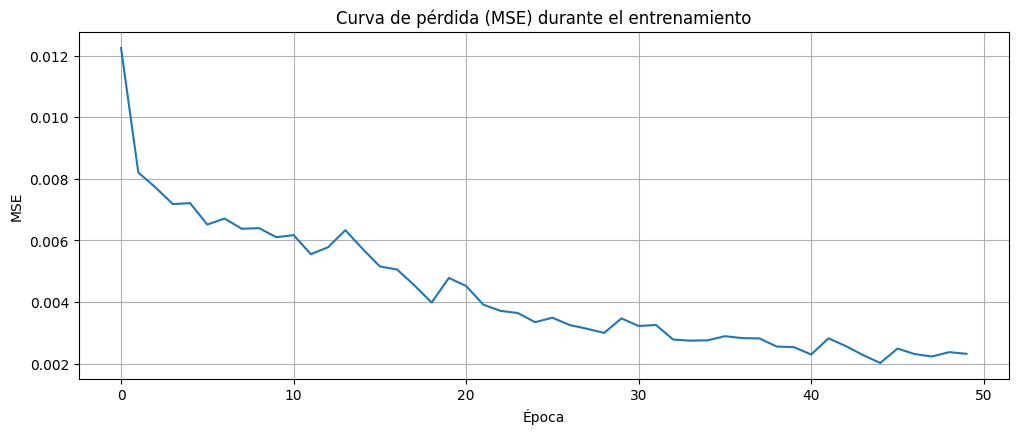

Épocas entrenadas: 50


In [19]:
parada = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
historial = modelo_lstm.fit(generador_train, epochs=50, callbacks=[parada], verbose=2)

plt.plot(historial.history["loss"])
plt.title("Curva de pérdida (MSE) durante el entrenamiento")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.show()
print("Épocas entrenadas:", len(historial.history["loss"]))

**Resultado:** la pérdida cae con rapidez en las primeras épocas (de 0,0122 en la primera a menos de 0,008 en la tercera) y después desciende lentamente hasta estabilizarse en torno a **0,0022–0,0025** (en escala [0, 1]). El entrenamiento completó las **50 épocas** sin que el EarlyStopping llegara a activarse: la pérdida seguía mejorando ligeramente, aunque ya con ganancias marginales, lo que indica que el modelo está prácticamente convergido.

## 3.6 Predicciones sobre el conjunto de test
Genero las predicciones y las devuelvo a unidades reales con `inverse_transform`. Evalúo el error con tres métricas:
- **MAE:** error medio absoluto, en unidades de ventas.
- **RMSE:** raíz del error cuadrático medio; penaliza más los errores grandes.
- **MAPE:** error medio en porcentaje, la métrica más fácil de interpretar.

Como referencia uso un **modelo ingenuo estacional**, que predice para cada mes el valor del mismo mes del año anterior. Si la LSTM no lo mejora, no aporta valor frente a la regla más simple posible.

In [20]:
pred_esc = modelo_lstm.predict(generador_test, verbose=0)
pred = scaler.inverse_transform(pred_esc).flatten()     # Vuelta a unidades reales

resultados = test.copy()
resultados.columns = ["real"]
resultados["lstm"] = pred

mae = mean_absolute_error(resultados["real"], resultados["lstm"])
rmse = np.sqrt(mean_squared_error(resultados["real"], resultados["lstm"]))
mape = np.mean(np.abs((resultados["real"] - resultados["lstm"]) / resultados["real"])) * 100
print(f"LSTM             → MAE: {mae:,.1f} | RMSE: {rmse:,.1f} | MAPE: {mape:.2f}%")

naive = serie["ventas"].shift(12).loc[test.index]
mape_naive = np.mean(np.abs((resultados["real"] - naive) / resultados["real"])) * 100
print(f"Naive estacional → MAPE: {mape_naive:.2f}%")

resultados.round(1)

LSTM             → MAE: 1,193.7 | RMSE: 1,504.4 | MAPE: 8.41%
Naive estacional → MAPE: 3.88%


,real,lstm
fecha,,
2023-06-01,17602,17241.099609
2023-07-01,14275,16916.300781
2023-08-01,16867,16922.400391
2023-09-01,15702,17213.900391
2023-10-01,16014,16880.400391
2023-11-01,17296,17325.099609
2023-12-01,17449,17359.599609
2024-01-01,12161,15076.599609
2024-02-01,13721,15706.200195


## 3.7 Valores reales vs. predichos
Represento los valores reales del test frente a las predicciones de la LSTM (con el entrenamiento desde 2018 como contexto) y el error mensual (real − predicho).

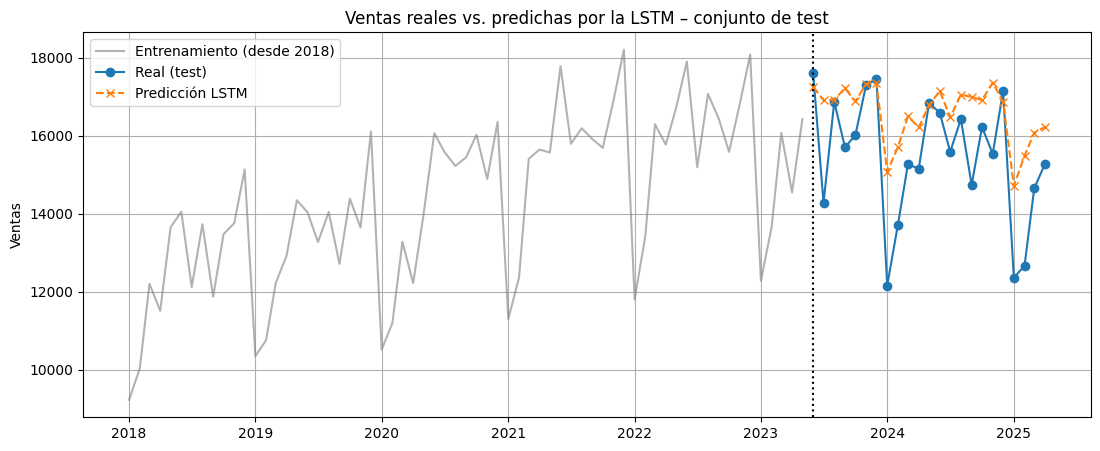

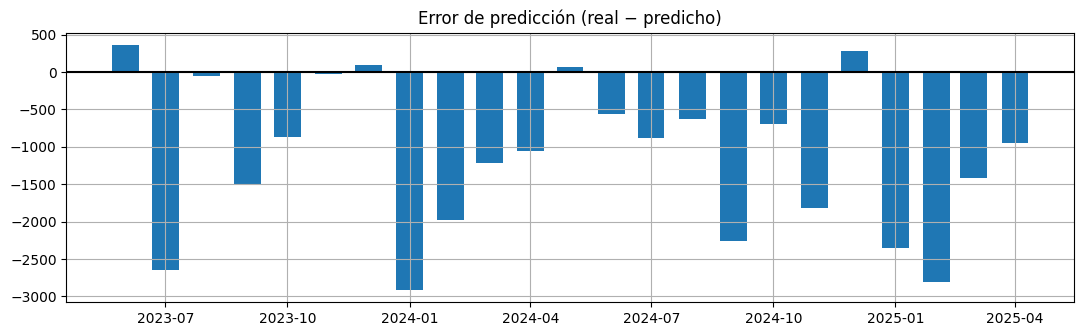

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.loc["2018":], label="Entrenamiento (desde 2018)", color="grey", alpha=0.6)
ax.plot(resultados["real"], label="Real (test)", marker="o")
ax.plot(resultados["lstm"], label="Predicción LSTM", marker="x", ls="--")
ax.axvline(pd.Timestamp(FECHA_CORTE), color="k", ls=":")
ax.set_title("Ventas reales vs. predichas por la LSTM – conjunto de test")
ax.set_ylabel("Ventas"); ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.bar(resultados.index, resultados["real"] - resultados["lstm"], width=20)
ax.axhline(0, color="k")
ax.set_title("Error de predicción (real − predicho)")
plt.show()

**Comentario de los resultados:**

| Modelo | MAE | RMSE | MAPE |
|---|---|---|---|
| LSTM | 1.193,7 | 1.504,4 | 8,41% |
| Naive estacional (mismo mes del año anterior) | – | – | 3,88% |

1. **Patrón estacional:** la LSTM reproduce la **dirección** del ciclo anual: anticipa las caídas de enero de 2024 y enero de 2025 y la recuperación posterior. Sin embargo, **subestima su amplitud**. Las predicciones se mueven entre unas 14.700 y 17.400, mientras que las ventas reales van de 12.161 a 17.602. La red capta que enero es un mes bajo, pero no cuánto.
2. **Picos y valles:** en los picos acierta bastante bien (diciembre de 2023: 17.360 predicho frente a 17.449 real; junio de 2023: 17.241 frente a 17.602). Donde falla es en los **valles**: en enero de 2024 predice 15.077 frente a 12.161 reales (un error del 24%) y en enero de 2025, 14.714 frente a 12.359. Las redes entrenadas con MSE tienden a suavizar los extremos, y aquí la suavización recae sobre los mínimos.
3. **Sesgo:** en el gráfico de errores la gran mayoría de las barras son negativas: la LSTM **sobrevalora las ventas en 19 de los 23 meses**. La explicación está en el cambio de régimen: el entrenamiento está dominado por treinta años de crecimiento continuo, y la red ha aprendido a proyectar esa subida. En el periodo de test las ventas se estancan y retroceden, y el modelo sigue anticipando un nivel más alto del que se produce. No es un problema de extrapolación fuera de rango (el test está dentro de [0, 1]), sino de **dinámica**: la red espera un crecimiento que ya no existe.
4. **Comparación con la referencia:** el modelo ingenuo estacional obtiene un MAPE del 3,88%, frente al 8,41% de la LSTM, así que **la LSTM no mejora la regla más simple posible**; su error es más del doble. Tiene sentido: con las ventas estancadas, repetir el valor del año anterior es una predicción muy buena, mientras que la red arrastra la tendencia alcista del pasado.
5. **Limitaciones y mejoras:** 365 ventanas es un volumen reducido para una red neuronal, y el cambio de tendencia entre entrenamiento y test dificulta la generalización. Posibles mejoras: entrenar sobre la **serie diferenciada estacionalmente** (para que la red aprenda variaciones y no niveles, y no arrastre la tendencia), usar el logaritmo de las ventas, ampliar la ventana a 24 meses, validar con una parte final del entrenamiento para ajustar el número de épocas, o añadir variables de calendario como entradas.

*Nota: los pesos iniciales y el orden de las operaciones pueden variar entre equipos (CPU/GPU), por lo que las cifras exactas de esta parte pueden cambiar al reejecutar el cuaderno.*

## 3.8 Comparación final: SARIMA vs. LSTM en el periodo de test
Para cerrar el análisis comparo los dos enfoques en las mismas condiciones. Reajusto el SARIMA(1,1,1)(0,1,1)₁₂ **solo con los datos de entrenamiento** (anteriores a junio de 2023) y genero predicciones **un paso adelante** para los 23 meses de test. Es el mismo esquema que la LSTM, que en cada mes usa los valores reales de los 12 meses anteriores. Los parámetros del modelo no se reestiman con los datos de test (`refit=False`), así que no hay fuga de información.

,MAE,MAPE (%)
"SARIMA(1,1,1)(0,1,1,12)",522.58,3.45
Naive estacional,595.39,3.88
LSTM,1193.70,8.41


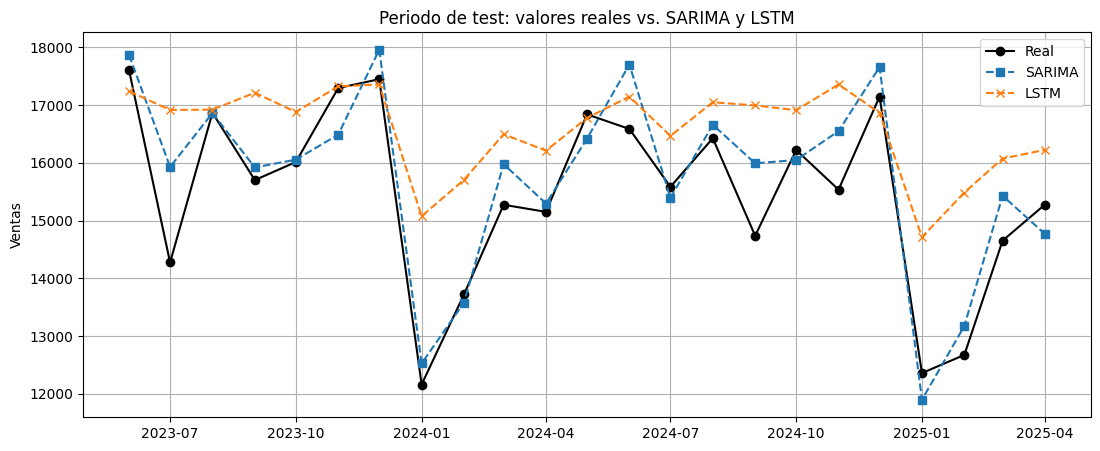

In [22]:
# Esta celda es autónoma: vuelve a leer el CSV y no requiere reejecutar la LSTM
serie_c = pd.read_csv(RUTA, parse_dates=[0], index_col=0).iloc[:, 0].asfreq("MS").astype(float)
train_c = serie_c[serie_c.index < "2023-06-01"]
test_c = serie_c[serie_c.index >= "2023-06-01"]

sarima_train = SARIMAX(train_c, order=(1,1,1), seasonal_order=(0,1,1,12),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
# Predicción un paso adelante: se incorporan los datos reales de test sin reestimar parámetros
pred_sarima = sarima_train.append(test_c, refit=False).predict(start=test_c.index[0], end=test_c.index[-1])
pred_naive = serie_c.shift(12).loc[test_c.index]

def metricas(real, pred):
    return {"MAE": mean_absolute_error(real, pred),
            "MAPE (%)": np.mean(np.abs((real - pred) / real)) * 100}

comparacion = pd.DataFrame({
    "SARIMA(1,1,1)(0,1,1,12)": metricas(test_c, pred_sarima),
    "Naive estacional": metricas(test_c, pred_naive),
    "LSTM": {"MAE": 1193.7, "MAPE (%)": 8.41},   # resultados obtenidos en el apartado 3.6
}).T.round(2)
display(comparacion)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_c, label="Real", marker="o", color="black")
ax.plot(pred_sarima, label="SARIMA", marker="s", ls="--")
ax.plot(resultados["lstm"] if "resultados" in globals() else [], label="LSTM", marker="x", ls="--")
ax.set_title("Periodo de test: valores reales vs. SARIMA y LSTM")
ax.set_ylabel("Ventas"); ax.legend(); plt.show()

**Comentario:**

| Modelo | MAE | MAPE |
|---|---|---|
| **SARIMA(1,1,1)(0,1,1)₁₂** | **522,58** | **3,45%** |
| Naive estacional | 595,39 | 3,88% |
| LSTM | 1.193,70 | 8,41% |

- **El SARIMA es el mejor de los tres** y el único que supera al modelo ingenuo estacional. Su error es **menos de la mitad** que el de la LSTM.
- A diferencia de la LSTM, el SARIMA también tiende a sobrevalorar ligeramente (15 de los 23 meses, frente a 19 de la LSTM), pero con errores mucho menores, y **reproduce bien los valles de enero** (enero de 2024: 12.526 predicho frente a 12.161 real, cuando la LSTM predecía 15.077). (enero de 2024: 12.526 predicho frente a 12.161 real, cuando la LSTM predecía 15.077).
- La razón es estructural: al trabajar sobre la serie diferenciada, el SARIMA modela **variaciones** respecto al año anterior y se adapta enseguida al estancamiento de 2023–2024. La LSTM, entrenada sobre **niveles**, sigue proyectando el crecimiento del pasado.
- Esto confirma que un modelo puede no superar el test de Ljung-Box (sus residuos no son ruido blanco) y aun así predecir bien: el diagnóstico indica que el modelo **se puede mejorar**, no que sea inútil.

# 4. Conclusiones
- **Datos:** la serie de ventas mensuales de alcohol (enero de 1992 a abril de 2025, 400 observaciones) **no contiene valores faltantes**; aun así, dejé definida una estrategia de imputación por interpolación temporal. La serie presenta una **tendencia creciente hasta 2021**, un **estancamiento con ligero retroceso en 2023–2024**, una **estacionalidad anual marcada** (máximo en diciembre, mínimo en enero) y una **varianza creciente** con el nivel.
- **Estacionariedad:** el test ADF confirmó que la serie original no es estacionaria (p = 0,9248). Tras aplicar una diferencia regular y otra estacional (d = 1, D = 1, s = 12), la serie resultante sí lo es (estadístico −6,93, p ≈ 0).
- **SARIMA:** a partir de los gráficos ACF y PACF propuse un **SARIMA(1,1,1)(0,1,1)₁₂**, con todos los coeficientes significativos y mejor AIC que el airline model. Sin embargo, **el test de Ljung-Box rechaza que los residuos sean ruido blanco** en los lags 12 y 24 (p ≈ 0). La autocorrelación restante se explica por el efecto calendario, la heterocedasticidad y el cambio estructural de la pandemia, y sugiere ampliar el modelo (más términos AR, logaritmos y regresores de calendario).
- **LSTM vs. SARIMA:** un modelo simple de LSTM (50 neuronas, ventana de 12 meses) capta la dirección del ciclo estacional, pero **sobrevalora las ventas en 19 de los 23 meses de test**, sobre todo en los valles de enero, porque proyecta la tendencia de crecimiento aprendida en el entrenamiento. Obtiene un MAPE del 8,41%. En las mismas condiciones, el SARIMA logra un **3,45%**, el único resultado que mejora al modelo ingenuo estacional (3,88%).
- **Valoración personal:** este ejercicio muestra que un modelo más complejo no garantiza mejores resultados, sobre todo cuando cambia el régimen de la serie. Desde mi experiencia en el sector bancario, antes de dar por válido cualquier modelo lo compararía siempre con una referencia sencilla, y para series mensuales cortas y con estacionalidad clara preferiría un modelo estadístico como el SARIMA. Es interpretable y, sobre todo, **se puede diagnosticar**: aquí el test de Ljung-Box nos ha dicho exactamente qué le falta al modelo, algo que la LSTM no ofrece de forma directa. En entornos regulados, la transparencia y la capacidad de justificar un modelo son tan importantes como su precisión. Reservaría las redes neuronales para contextos con más datos o con variables explicativas adicionales.